In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
# import randomforest
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score

In [7]:
def load_data(path):
    df=pd.read_csv(path)
    df["TEST_DATE"] = pd.to_datetime(df["TEST_DATE"])
    df = df.sort_values("TEST_DATE").dropna(subset=["OIL"]).reset_index(drop=True)
    df = df[df["OIL"] > 0].reset_index(drop=True)
    return df

In [8]:
def visualize_data(df):
    plt.figure(figsize=(12, 6))
    sns.lineplot(x="TEST_DATE", y="OIL", data=df)
    plt.title("Oil Production Over Time")
    plt.xlabel("Date")
    plt.ylabel("Oil Production")
    plt.show()

In [9]:
def create_dataset(feature_series, target_series, time_steps=30):
    Xs, ys, indices = [], [], []
    for i in range(time_steps, len(feature_series)):
        Xs.append(feature_series[i - time_steps:i])
        ys.append(target_series[i])
        indices.append(i)
    return np.array(Xs), np.array(ys), np.array(indices)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


/tmp/ipykernel_256337/2224772952.py:3: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["TEST_DATE"] = pd.to_datetime(df["TEST_DATE"])


Best CV RMSE: 0.2210
Best Params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 2, 'max_features': 'log2', 'max_depth': 10}
Test OIL MSE : 3586.6925
Test OIL RMSE: 59.8890
Test OIL R2  : 0.1038


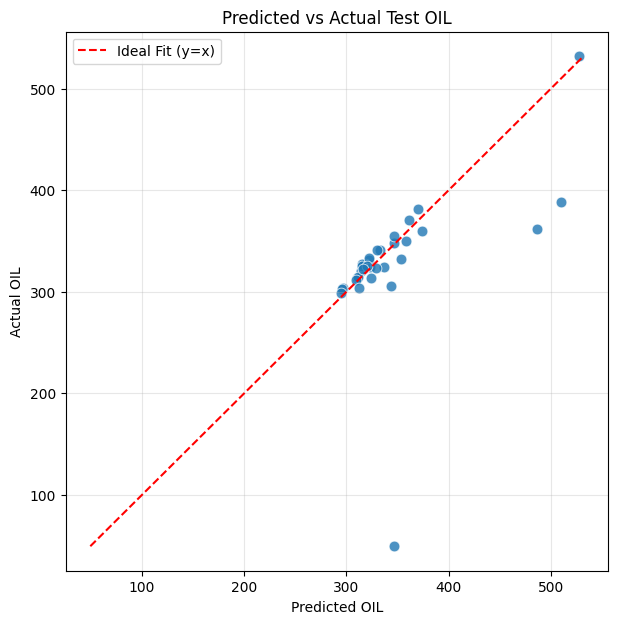

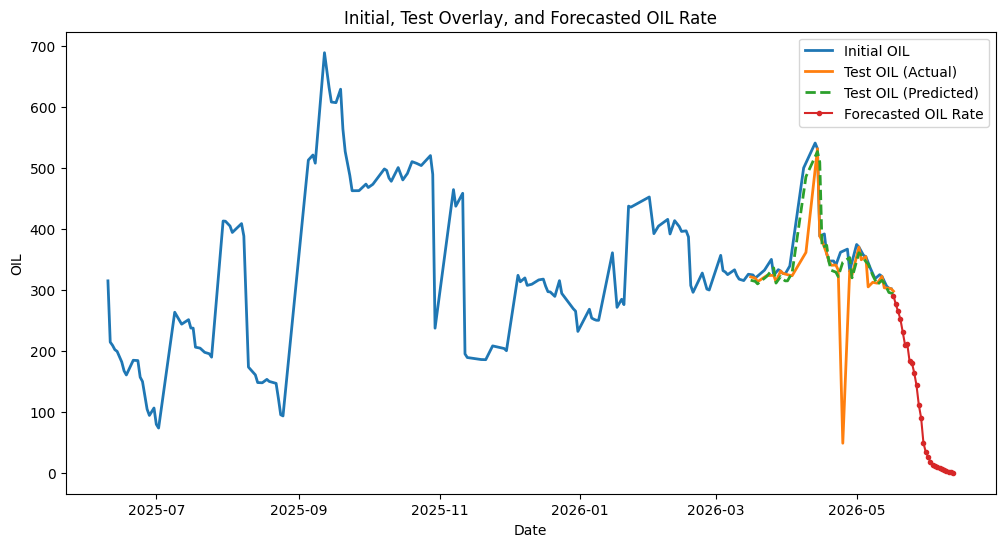

In [17]:
def main():
    # Load data
    path = "/home/rian/python_project/myvenv/dca_ml/data/test_data.csv"
    df = load_data(path)
    df['LN_OIL'] = np.log(df['OIL'])
    df['OIL_NEXT'] = df['OIL'].shift(-1)
    df['NEXT_TEST_DATE'] = df['TEST_DATE'].shift(-1)
    df['DELTA_T'] = (df['NEXT_TEST_DATE'] - df['TEST_DATE']).dt.total_seconds() / 86400.0
    df.loc[df['DELTA_T'] <= 0, 'DELTA_T'] = np.nan
    df['DEC_RATIO'] = np.log(df['OIL'] / df['OIL_NEXT']) / df['DELTA_T']
    df.loc[df['DEC_RATIO'] < 0, 'DEC_RATIO'] = np.nan
    df = df.dropna(subset=['DEC_RATIO', 'OIL_NEXT', 'NEXT_TEST_DATE', 'DELTA_T']).reset_index(drop=True)

    # Split data with 80% for training and 20% for testing
    train_size = int(len(df) * 0.8)
    feature_series = df["LN_OIL"].values
    target_series = df["DEC_RATIO"].values

    # Create supervised features with a rolling window of 30 past LN_OIL values
    # and target as decline ratio ln(q(t)/q(t+1)) / delta_t.
    time_steps = 30
    X_all, y_all, target_indices = create_dataset(feature_series, target_series, time_steps=time_steps)

    train_mask = target_indices < train_size
    test_mask = ~train_mask

    X_train, y_train = X_all[train_mask], y_all[train_mask]
    X_test = X_all[test_mask]
    test_target_indices = target_indices[test_mask]

    # Train with time-series CV using randomized hyperparameter search.
    if len(X_train) >= 20:
        n_splits = min(5, len(X_train) - 1)
        tscv = TimeSeriesSplit(n_splits=n_splits)

        base_model = RandomForestRegressor(random_state=42, n_jobs=-1)
        param_distributions = {
            'n_estimators': [200, 300, 500, 700],
            'max_depth': [None, 5, 10, 20, 30],
            'min_samples_split': [2, 5, 10],
            'min_samples_leaf': [1, 2, 4],
            'max_features': ['sqrt', 'log2', 0.8]
        }

        search = RandomizedSearchCV(
            estimator=base_model,
            param_distributions=param_distributions,
            n_iter=20,
            scoring='neg_mean_squared_error',
            cv=tscv,
            random_state=42,
            n_jobs=-1,
            verbose=1
        )
        search.fit(X_train, y_train)

        model = search.best_estimator_
        best_cv_rmse = np.sqrt(-search.best_score_)
        print(f"Best CV RMSE: {best_cv_rmse:.4f}")
        print(f"Best Params: {search.best_params_}")
    else:
        print("Not enough training samples for CV search. Using default RandomForestRegressor.")
        model = RandomForestRegressor(
            n_estimators=300,
            random_state=42,
            n_jobs=-1
        )
        model.fit(X_train, y_train)

    # Predict test decline ratio, then convert to new OIL: q(t+1)=q(t)*exp(-decline_ratio*delta_t).
    predicted_test_dec_ratio = model.predict(X_test)
    oil_at_t = df['OIL'].iloc[test_target_indices].to_numpy()
    test_delta_t = df['DELTA_T'].iloc[test_target_indices].to_numpy()
    predicted_test_oil = oil_at_t * np.exp(-predicted_test_dec_ratio * test_delta_t)
    actual_test_oil = df['OIL_NEXT'].iloc[test_target_indices].to_numpy()
    test_dates = df['NEXT_TEST_DATE'].iloc[test_target_indices].to_numpy()

    # Evaluate predictive performance on test OIL values.
    test_mse = mean_squared_error(actual_test_oil, predicted_test_oil)
    test_rmse = np.sqrt(test_mse)
    test_r2 = r2_score(actual_test_oil, predicted_test_oil)
    print(f"Test OIL MSE : {test_mse:.4f}")
    print(f"Test OIL RMSE: {test_rmse:.4f}")
    print(f"Test OIL R2  : {test_r2:.4f}")

    # Scatter plot: Predicted OIL vs Actual OIL on test set.
    plt.figure(figsize=(7, 7))
    sns.scatterplot(x=predicted_test_oil, y=actual_test_oil, s=60, alpha=0.8)
    min_oil = min(predicted_test_oil.min(), actual_test_oil.min())
    max_oil = max(predicted_test_oil.max(), actual_test_oil.max())
    plt.plot([min_oil, max_oil], [min_oil, max_oil], 'r--', linewidth=1.5, label='Ideal Fit (y=x)')
    plt.title("Predicted vs Actual Test OIL")
    plt.xlabel("Predicted OIL")
    plt.ylabel("Actual OIL")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

    # Recursive forecasting with cumulative t increments: 1, 2, 3, ... days from last historical date.
    future_oil_predictions = []
    future_dates = []
    history_ln = feature_series[-time_steps:].tolist()
    q_last_observed = np.exp(history_ln[-1])
    q_t = q_last_observed
    forecast_t = 0.0

    freq = pd.infer_freq(df["TEST_DATE"]) or 'D'
    date_offset = pd.tseries.frequencies.to_offset(freq)
    current_date = df["TEST_DATE"].iloc[-1]

    # Stop forecasting when OIL reaches 1.
    stop_oil = 1

    while q_t > stop_oil:
        current_input = np.array(history_ln[-time_steps:]).reshape(1, -1)
        pred_dec_ratio = model.predict(current_input)[0]

        next_date = current_date + date_offset
        step_t = (next_date - current_date) / np.timedelta64(1, 'D')
        if step_t <= 0:
            step_t = 1.0
        forecast_t += step_t

        # q(t) = q(last_date) * exp(-decline_ratio * cumulative_t).
        q_t = q_last_observed * np.exp(-pred_dec_ratio * forecast_t)
        current_date = next_date

        if q_t <= stop_oil:
            q_t = stop_oil
            future_oil_predictions.append(q_t)
            future_dates.append(current_date)
            break

        future_oil_predictions.append(q_t)
        future_dates.append(current_date)
        history_ln.append(np.log(max(q_t, 1e-9)))

    # Single combined plot: historical OIL, test actual/predicted OIL, and future forecast.
    plt.figure(figsize=(12, 6))
    plt.plot(df["TEST_DATE"], df["OIL"], label="Initial OIL", linewidth=2)
    if len(test_dates) > 0:
        plt.plot(test_dates, actual_test_oil, label="Test OIL (Actual)", linewidth=2)
        plt.plot(test_dates, predicted_test_oil, label="Test OIL (Predicted)", linewidth=2, linestyle='--')
    if len(future_oil_predictions) > 0:
        plt.plot(future_dates, future_oil_predictions, label="Forecasted OIL Rate", marker='o', markersize=3)
    plt.title("Initial, Test Overlay, and Forecasted OIL Rate")
    plt.xlabel("Date")
    plt.ylabel("OIL")
    plt.legend()
    plt.show()

if __name__ == "__main__":
    main()